In [2]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
import torchvision 
from torchvision.datasets import CIFAR10

In [4]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(
    root="./cnn_data",
    train=True,
    download=True,
    transform=transform
)

testset = CIFAR10(
    root="./cnn_data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [01:15<00:00, 2.26MB/s]   


In [6]:
trainloader = DataLoader(
    trainset,batch_size=64,shuffle=True
)
testloader = DataLoader(
    testset,batch_size=64
)

In [28]:
# Build the cnn
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

        )

        self.fc_layers = nn.Sequential(

            nn.Linear(4 * 4 * 128, 256),
            nn.ReLU(),
            nn.Linear(256, 10),

        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = x.view(x.size(0), -1)

        x = self.fc_layers(x)

        return x

In [29]:
model = CNN() 

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [37]:
epochs = 10
for epoch in range(epochs):
    epoch_training_loss = 0.0
    for images,labels in trainloader: 
        optimizer.zero_grad()
        output = model.forward(images)
        loss = criterion(output,labels)
        loss.backward() # BackPropogation 
        optimizer.step() # Update parameters
        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")

epoch=1/10 & loss=0.842823229215639
epoch=2/10 & loss=0.6914530189522087
epoch=3/10 & loss=0.5768529403468837
epoch=4/10 & loss=0.47399604810244594
epoch=5/10 & loss=0.38017728995255495
epoch=6/10 & loss=0.3003632450843101
epoch=7/10 & loss=0.23521439918814718
epoch=8/10 & loss=0.17707741255764767
epoch=9/10 & loss=0.14329628427239025
epoch=10/10 & loss=0.12162153115448401


In [42]:
# evaluate the cnn 

correct_labels = 0
total_lables = 0
model.eval()
with torch.no_grad():
    for images ,labels in testloader: 
        outputs = model.forward(images)
        _, predicted = torch.max(outputs,1)
        correct_labels += (predicted==labels).sum().item()
        total_lables+=labels.size(0)

print(f"accuracy = {correct_labels/total_lables * 100}")


accuracy = 74.85000000000001


epoch=1/10 & loss=0.10727561472217216
epoch=2/10 & loss=0.09333188587304234
epoch=3/10 & loss=0.08452197517115918
epoch=4/10 & loss=0.0875289647341551
epoch=5/10 & loss=0.0767565858982089
epoch=6/10 & loss=0.07493874842546347
epoch=7/10 & loss=0.06996198844038369
epoch=8/10 & loss=0.07182435020167247
epoch=9/10 & loss=0.0684329927681595
epoch=10/10 & loss=0.06913475630968056


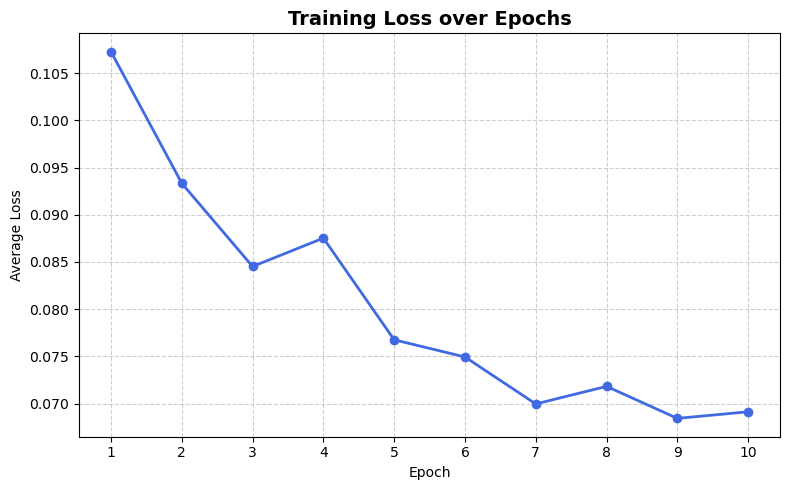

Loss curve saved as loss_curve.png


In [43]:
import matplotlib.pyplot as plt
 
# ─── 1. Update your training loop to track loss ───────────────────────────────
# Replace your existing training loop with this:
 
epochs = 10
loss_history = []  # ✅ Added
 
for epoch in range(epochs):
    epoch_training_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        output = model.forward(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        epoch_training_loss += loss.item()
 
    avg_loss = epoch_training_loss / len(trainloader)
    loss_history.append(avg_loss)  # ✅ Added
    print(f"epoch={epoch+1}/{epochs} & loss={avg_loss}")
 
 
# ─── 2. Plot the loss curve (run this in a new cell after training) ────────────
 
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='royalblue', linewidth=2, markersize=6)
plt.title("Training Loss over Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)  # ✅ Saves as image for README
plt.show()
print("Loss curve saved as loss_curve.png")
 